In [1]:
import pandas as pd
import numpy as np

from typing import List, Tuple, Dict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RepeatedStratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC, LinearSVC # Support Vector Machine Classifier. Unused as it is too slow
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, FunctionTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score, recall_score, classification_report, balanced_accuracy_score, balanced_accuracy_score, cohen_kappa_score, mean_absolute_error, matthews_corrcoef
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE # Oversampling
from imblearn.under_sampling import RandomUnderSampler # Undersampling
from collections import defaultdict
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.multioutput import MultiOutputClassifier
import joblib, os, json, re

In [3]:
df = pd.read_csv('data_export.csv')

In [4]:
# Display all columns when showing the dataframe
pd.options.display.max_rows = None
pd.set_option('display.max_columns', None)

In [5]:
df.head()

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,Q4I,Q4E,Q5A,Q5I,Q5E,Q6A,Q6I,Q6E,Q7A,Q7I,Q7E,Q8A,Q8I,Q8E,Q9A,Q9I,Q9E,Q10A,Q10I,Q10E,Q11A,Q11I,Q11E,Q12A,Q12I,Q12E,Q13A,Q13I,Q13E,Q14A,Q14I,Q14E,Q15A,Q15I,Q15E,Q16A,Q16I,Q16E,Q17A,Q17I,Q17E,Q18A,Q18I,Q18E,Q19A,Q19I,Q19E,Q20A,Q20I,Q20E,Q21A,Q21I,Q21E,Q22A,Q22I,Q22E,Q23A,Q23I,Q23E,Q24A,Q24I,Q24E,Q25A,Q25I,Q25E,Q26A,Q26I,Q26E,Q27A,Q27I,Q27E,Q28A,Q28I,Q28E,Q29A,Q29I,Q29E,Q30A,Q30I,Q30E,Q31A,Q31I,Q31E,Q32A,Q32I,Q32E,Q33A,Q33I,Q33E,Q34A,Q34I,Q34E,Q35A,Q35I,Q35E,Q36A,Q36I,Q36E,Q37A,Q37I,Q37E,Q38A,Q38I,Q38E,Q39A,Q39I,Q39E,Q40A,Q40I,Q40E,Q41A,Q41I,Q41E,Q42A,Q42I,Q42E,country,source,introelapse,testelapse,surveyelapse,TIPI1,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10,VCL1,VCL2,VCL3,VCL4,VCL5,VCL6,VCL7,VCL8,VCL9,VCL10,VCL11,VCL12,VCL13,VCL14,VCL15,VCL16,education,urban,gender,engnat,age,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize,major
0,4,28,3890,4,25,2122,2,16,1944,4,8,2044,4,34,2153,4,33,2416,4,10,2818,4,13,2259,2,21,5541,1,38,4441,4,31,2451,4,24,3325,4,14,1416,4,37,5021,4,27,2342,4,39,2480,3,6,2476,4,35,1627,3,17,9050,3,30,7001,1,11,4719,4,20,2984,4,36,1313,4,42,2444,4,1,9880,4,2,4695,4,5,1677,3,4,6723,4,3,5953,2,26,8062,4,12,5560,4,7,3032,2,29,3316,3,40,3563,4,23,5594,4,41,1477,1,18,3885,2,9,5265,4,19,1892,3,22,4228,4,32,1574,4,15,2969,IN,2,19,167,166,1,5,7,7,7,7,7,5,1,1,1,0,0,1,1,0,1,0,0,1,0,0,0,1,1,1,2,3,2,2,16,1,1,1,12,1,10,2,1,2,NaN
1,4,2,8118,1,36,2890,2,35,4777,3,28,3090,4,10,5078,4,40,2790,3,18,3408,4,1,8342,3,37,916,2,32,1537,2,21,3926,2,25,3691,4,26,2004,4,4,8888,3,27,4109,3,19,4058,4,12,3692,2,6,3373,1,23,6015,1,16,3023,2,22,2670,3,3,5727,1,39,3641,2,33,2670,2,7,7649,3,11,2537,3,5,2907,4,9,1685,3,41,4726,3,17,6063,2,20,3307,3,14,4995,3,38,2505,2,34,2540,2,31,4359,3,15,3925,4,13,4609,2,30,3755,2,42,2323,1,24,5713,2,8,1334,2,29,5562,US,2,1,193,186,6,5,4,7,5,4,7,7,1,5,1,1,0,1,1,0,0,0,0,1,0,0,0,1,1,1,2,3,2,1,16,2,1,2,7,0,70,2,1,4,NaN
2,3,7,5784,1,33,4373,4,41,3242,1,13,6470,4,11,3927,3,9,3704,1,17,4550,3,5,3021,2,32,5864,4,21,3722,2,10,3424,1,36,3236,4,23,2489,1,34,7290,4,12,6587,4,22,3627,4,38,2905,2,18,2998,2,8,10233,1,16,4258,4,28,2888,3,4,59592,2,3,11732,4,2,8834,2,29,7358,1,30,4928,2,15,3036,1,19,4127,2,37,3934,2,26,10782,4,1,8273,3,39,3501,1,27,3824,4,25,2141,3,6,17461,4,24,1557,4,40,4446,4,42,1883,2,35,5790,2,14,4432,1,20,2203,4,31,5768,PL,2,5,271,122,2,5,2,2,5,6,5,5,3,2,1,0,0,1,1,0,0,0,0,0,1,0,0,1,1,1,2,3,2,2,17,2,1,1,4,3,60,1,1,3,NaN
3,2,23,5081,3,11,6837,2,37,5521,1,27,4556,3,28,3269,3,26,3231,4,2,7138,2,19,3079,3,31,9650,3,17,4179,2,5,5928,1,21,2838,1,20,2560,4,29,5139,2,22,3597,2,35,3336,3,10,4506,1,14,2695,1,25,8128,2,15,3125,1,6,4061,1,40,4272,1,12,4029,1,9,5630,1,18,30631,2,24,9870,4,4,2411,1,16,9478,3,1,7618,3,32,12639,3,34,5378,1,41,8923,2,38,2977,4,3,5620,1,7,16760,1,8,6427,2,39,3760,1,13,4112,3,42,2769,4,33,4432,4,30,3643,2,36,3698,US,2,3,261,336,1,1,7,4,6,4,6,1,6,1,1,0,0,1,1,0,0,0,0,1,0,0,0,1,1,1,1,3,2,1,13,2,1,2,4,5,70,2,1,5,biology
4,2,36,3215,2,13,7731,3,5,4156,4,10,2802,4,2,5628,2,9,6522,4,34,2374,4,11,3054,4,7,2975,3,14,3524,2,33,3033,4,23,2132,4,17,1314,4,16,3181,4,26,2249,3,19,2623,4,35,3093,4,38,7098,4,37,1938,4,15,3502,3,32,4776,3,18,4463,4,4,2436,2,40,4047,4,31,3787,4,42,2102,2,1,12351,4,3,2410,2,22,5056,4,39,3343,3,27,3012,4,20,3520,4,8,1868,4,25,2536,3,24,3725,4,30,2130,3,29,3952,3,21,10694,3,41,3231,4,12,3604,4,28,1950,3,6,6265,MY,2,1766,164,157,2,5,3,6,5,5,5,6,3,3,1,1,0,1,1,0,0,1,0,1,0,0,1,1,1,1,3,2,2,2,19,2,2,3,10,1,10,2,1,4,Psychology


## Data Cleaning and Imputation Function

In [6]:
# ----- Scales & columns -----
DASS_DEP = [3,5,10,13,16,17,21,24,26,31,34,37,38,42]
DASS_ANX = [2,4,7,9,15,19,20,23,25,28,30,36,40,41]
DASS_STR = [1,6,8,11,12,14,18,22,27,29,32,33,35,39]

DASS_A = [f'Q{i}A' for i in range(1,43)]
TIPI   = [f'TIPI{i}' for i in range(1,11)]
TIPI_REV = {2,4,6,8,10}  # reverse-keyed items

CAT_COLS = [
    'education','urban','gender','engnat','hand','religion','orientation',
    'race','voted','married','country','screensize','uniquenetworklocation','source'
]

DUR_COLS = ['introelapse','testelapse','surveyelapse']

# ----- Helpers -----
def _clean_raw(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Drop columns with >95% missing
    df = df.dropna(axis = 1, thresh = int(0.05 * len(df)))

    # Normalize empties
    for c in ['country','major']:
        if c in out.columns:
            out[c] = out[c].replace('', np.nan)

    # Replacing out of range answers or invalid answers with NaN. For example value 0 according to the codebook
    cat_answer_range = {
        'education' : (1, 4),
        'urban'     : (1, 3),
        'engnat'    : (1, 2),
        'hand'      : (1, 3),
        'voted'     : (1, 2),
        'orientation': (1, 5),
        'gender'    : (1, 3),
        'married'   : (1, 3),
        'religion'  : (1, 12),
    }
    for c, (lo, hi) in cat_answer_range.items():
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors='coerce')
            out.loc[(out[c] < lo) | (out[c] > hi), c] = np.nan

    for c in TIPI:
        out[c] = pd.to_numeric(out[c], errors='coerce')
        out.loc[(out[c] < 1) | (out[c] > 7), c] = np.nan

    # Age: impossible ages -> NaN
    if 'age' in out.columns:
        out['age'] = pd.to_numeric(out['age'], errors='coerce')
        out.loc[out['age'] > 120, 'age'] = np.nan

    # Family size: conservative plausible band
    if 'familysize' in out.columns:
        out['familysize'] = pd.to_numeric(out['familysize'], errors='coerce')
        out.loc[(out['familysize'] < 0) | (out['familysize'] > 20), 'familysize'] = np.nan

    # Durations: negatives -> NaN; drop top 1% as NaN
    # TODO: Winsorizing(?)
    for col in DUR_COLS:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')
            out.loc[out[col] < 0, col] = np.nan
            q99 = out[col].quantile(0.99)
            out.loc[out[col] > q99, col] = np.nan

    # Per-item elapsed times Q?E
    dass_E = [c for c in out.columns if re.fullmatch(r'Q\d{1,2}E', c)]
    for col in dass_E:
        out[col] = pd.to_numeric(out[col], errors='coerce')
        out.loc[out[col] < 0, col] = np.nan
        q99 = out[col].quantile(0.99)
        out.loc[out[col] > q99, col] = np.nan

    return out

def impute_minimal(df: pd.DataFrame) -> pd.DataFrame:
    out = _clean_raw(df)

    # Numeric -> median
    num_cols = out.select_dtypes(include=[np.number]).columns.tolist()
    for col in num_cols:
        # Specific age imputation
        if col == 'age':
            out[col] = out.groupby(
                by = ['education', 'voted', 'married'] # Group by columns correlated with age
            )['age'].transform(func = lambda x: x.fillna(x.median())) # Impute age based on median of subgroups
            out[col] = out[col].fillna(out[col].median())

        if out[col].isna().any():
            out[col] = out[col].fillna(out[col].median())

    # Convert familysize and age to int datatype from decimal
    for col in ['familysize', 'age']:
        out[col] = out[col].astype('Int16')

    # Categoricals -> most frequent
    for col in CAT_COLS:
        if col in out.columns:
            out[col] = out[col].astype('category')
            if out[col].isna().any():
                out[col] = out[col].fillna(out[col].mode(dropna=True)[0])

    # Free text 'major' -> 'Unknown'
    if 'major' in out.columns:
        out['major'] = out['major'].fillna('Unknown')

    return out

def impute_domain_guided(df: pd.DataFrame) -> pd.DataFrame:
    out = _clean_raw(df)

    # DASS: person-mean within subscale if <=20% missing; else item median
    for items in [DASS_DEP, DASS_ANX, DASS_STR]:
        cols = [f'Q{i}A' for i in items]
        sub = out[cols].copy()
        miss = sub.isna().sum(axis=1)
        row_mean = sub.mean(axis=1)
        # up to 20% missing within subscale
        allow = miss.le(int(np.floor(0.2 * len(cols))))
        for c in cols:
            need = allow & sub[c].isna()
            out.loc[need, c] = row_mean[need].round().clip(1,4).astype('Int8')

    # TIPI: replace missing from reverse-keyed pair when available
    pair = {1:6, 6:1, 7:2, 2:7, 3:8, 8:3, 9:4, 4:9, 5:10, 10:5}
    for i in range(1,11):
        c = f'TIPI{i}'
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors='coerce')

    for i, j in pair.items():
        ci, cj = f'TIPI{i}', f'TIPI{j}'
        if ci in out.columns and cj in out.columns:
            m = out[ci].isna() & out[cj].notna()
            # if either is reverse-keyed, impute with 8 - partner; else copy
            if (i in TIPI_REV) ^ (j in TIPI_REV):
                out.loc[m, ci] = 8 - out.loc[m, cj]
            else:
                out.loc[m, ci] = out.loc[m, cj]

    # Any remaining DASS/TIPI -> item median (keep ordinal)
    for c in DASS_A:
        if c in out.columns:
            out[c] = out[c].round().clip(1,4).astype('Int8')
            if out[c].isna().any():
                out[c] = out[c].fillna(out[c].median()).astype('Int8')

    for c in TIPI:
        if c in out.columns:
            out[c] = out[c].round().clip(1,7).astype('Int8')
            if out[c].isna().any():
                out[c] = out[c].fillna(out[c].median()).astype('Int8')

    # VCL binary -> mode
    vcl = [c for c in out.columns if re.fullmatch(r'VCL\d{1,2}', c)]
    for c in vcl:
        out[c] = pd.to_numeric(out[c], errors='coerce').clip(0,1)
        if out[c].isna().any():
            out[c] = out[c].fillna(out[c].mode(dropna=True)[0])

    # Demographics/durations as in Minimal
    out = impute_minimal(out)
    return out

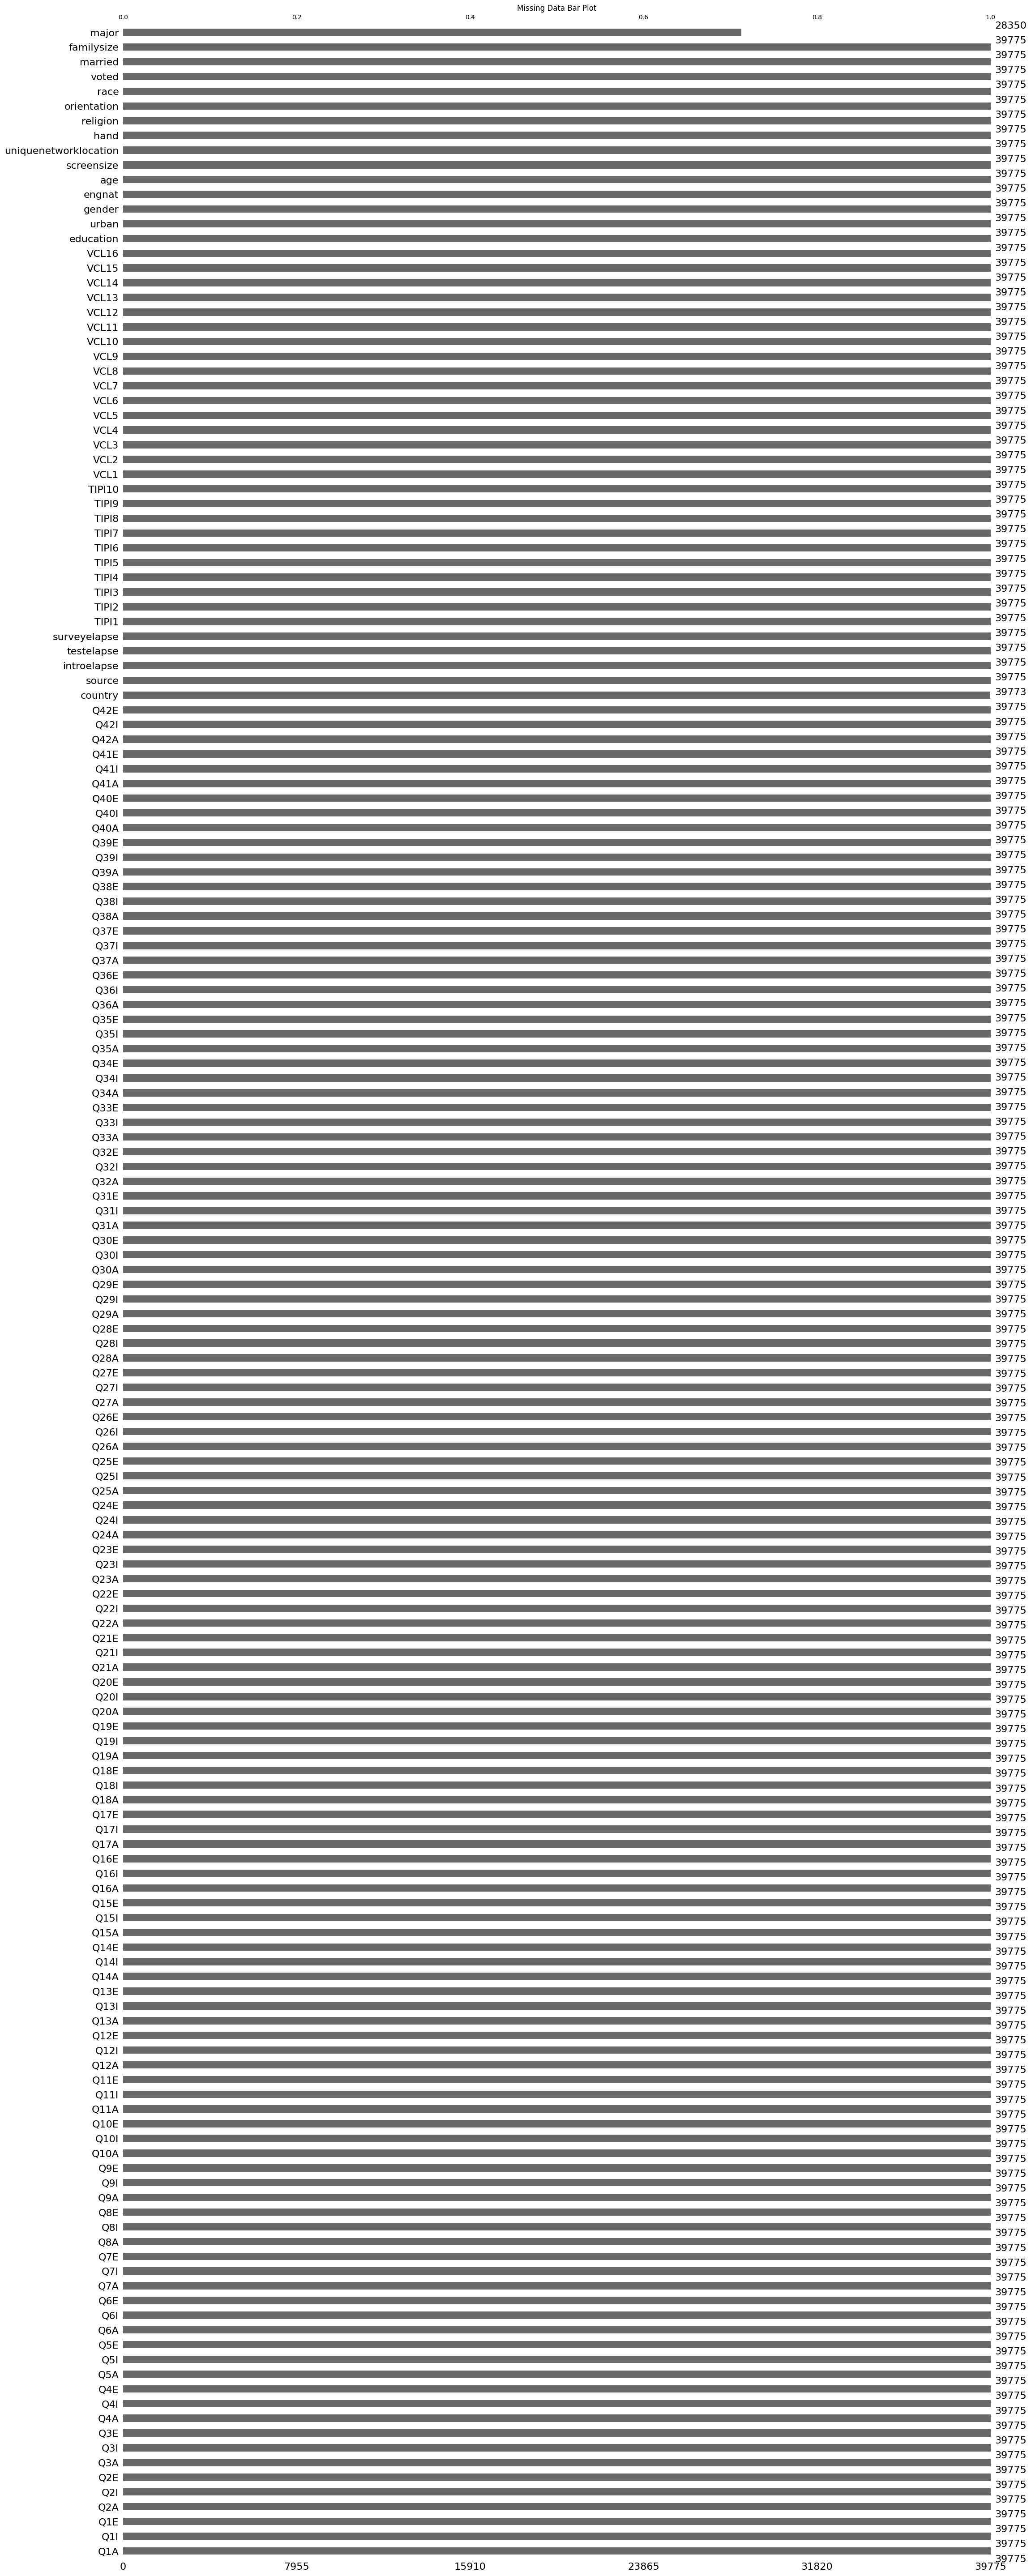

In [7]:
import missingno as msno
import matplotlib.pyplot as plt

# Visual Method : menggunakan plot bar untuk melihat data hilang

# package msno function .bar(nama_dataframe)
msno.bar(df)

# Title untuk plot bar
plt.title('Missing Data Bar Plot')
# Menampilkan plot
plt.show()

In [8]:
df = impute_domain_guided(df)

## Feature Engineering

In [9]:
# OCEAN and OCEAN Interaction Terms

# Create OCEAN Columns
df['openness']            = (df['TIPI5'] + (8 - df['TIPI10'])) / 2 # Average of two items, 
df['conscientiousness']   = (df['TIPI3'] + (8 - df['TIPI8']))  / 2 # one positively keyed and one negatively keyed (reversed)
df['extraversion']        = (df['TIPI1'] + (8 - df['TIPI6']))  / 2 # Reversed items: TIPI2, TIPI4, TIPI6, TIPI8, TIPI10
df['agreeableness']       = (df['TIPI7'] + (8 - df['TIPI2']))  / 2 
df['emotional_stability'] = (df['TIPI9'] + (8 - df['TIPI4']))  / 2

# Create OCEAN Interaction Terms
df['interaction_openness']            = df['TIPI5'] * (8 - df['TIPI10'])
df['interaction_conscientiousness']   = df['TIPI3'] * (8 - df['TIPI8'])
df['interaction_extraversion']        = df['TIPI1'] * (8 - df['TIPI6'])
df['interaction_agreeableness']       = df['TIPI7'] * (8 - df['TIPI2'])
df['interaction_emotional_stability'] = df['TIPI9'] * (8 - df['TIPI4'])

In [10]:
df.head()[['openness', 'conscientiousness', 'extraversion', 'agreeableness', 'emotional_stability']]

,openness,conscientiousness,extraversion,agreeableness,emotional_stability
0,7.0,5.0,1.0,5.0,1.0
1,4.0,2.5,5.0,5.0,1.0
2,5.5,2.5,2.0,4.0,4.5
3,6.5,7.0,2.5,6.5,5.0
4,5.0,2.5,2.5,4.0,2.5


In [11]:
df.head()[['interaction_openness', 'interaction_conscientiousness', 'interaction_extraversion', 'interaction_agreeableness', 'interaction_emotional_stability']]

,interaction_openness,interaction_conscientiousness,interaction_extraversion,interaction_agreeableness,interaction_emotional_stability
0,49,21,1,21,1
1,15,4,24,21,1
2,30,6,4,15,18
3,42,49,4,42,24
4,25,6,6,15,6


## Create Depression, Anxiety, and Stress Labels

In [ ]:
# DASS items
depression_items = ['Q3A','Q5A','Q10A','Q13A','Q16A','Q17A','Q21A','Q24A','Q26A','Q31A','Q34A','Q37A','Q38A','Q42A']  # 14
anxiety_items    = ['Q2A','Q4A','Q7A','Q9A','Q15A','Q19A','Q20A','Q23A','Q25A','Q28A','Q30A','Q36A','Q40A','Q41A']  # 14
stress_items     = ['Q1A','Q6A','Q8A','Q11A','Q12A','Q14A','Q18A','Q22A','Q27A','Q29A','Q32A','Q33A','Q35A','Q39A']  # 14
dass_all_items = depression_items + anxiety_items + stress_items

# Recode DASS items to 0-3 instead of 1-4
for c in dass_all_items:
    if df[c].isin([1,2,3,4]).all():
        df[c] = df[c].replace({1: 0, 2: 1, 3: 2, 4: 3})
    else:
        raise ValueError("Values already recoded")

# Create depression, anxiety, and stress scores
# Each item is rated on a 4-point scale (1 to 4)
df['depression'] = df[depression_items].sum(axis=1) # Subtract 1 from each item before summing
df['anxiety'] = df[anxiety_items].sum(axis=1) # Scoring needs the ordinal to be 0-3 instead of 1-4.
df['stress'] = df[stress_items].sum(axis=1)

# Multiclass mapping for Depression, Anxiety, and Stress
# Map the scores to their respective categories
def map_depression(score):
    if score <= 9:
        return 0 # 'Normal'
    elif score <= 13:
        return 1 # 'Mild'
    elif score <= 20:
        return 2 # 'Moderate'
    elif score <= 27:
        return 3 # 'Severe'
    else:
        return 4 # 'Extremely severe'
    
def map_anxiety(score):
    if score <= 7:
        return 0 # 'Normal'
    elif score <= 9:
        return 1 # 'Mild'
    elif score <= 14:
        return 2 # 'Moderate'
    elif score <= 19:
        return 3 # 'Severe'
    else:
        return 4 # 'Extremely severe'
    
def map_stress(score):
    if score <= 14:
        return 0 # 'Normal'
    elif score <= 18:
        return 1 # 'Mild'
    elif score <= 25:
        return 2 # 'Moderate'
    elif score <= 33:
        return 3 # 'Severe'
    else:
        return 4 # 'Extremely severe'

# Apply the mapping functions to create new columns
df['depression_severity'] = df['depression'].apply(map_depression)
df['anxiety_severity'] = df['anxiety'].apply(map_anxiety)
df['stress_severity'] = df['stress'].apply(map_stress)

In [21]:
df.head()[['depression', 'depression_severity'] + ['anxiety', 'anxiety_severity'] + ['stress', 'stress_severity']]

,depression,depression_severity,anxiety,anxiety_severity,stress,stress_severity
0,13,1,20,4,26,3
1,10,1,3,0,13,0
2,25,3,-2,0,3,0
3,2,0,3,0,2,0
4,18,2,26,4,15,1


In [12]:
# Show depression, anxiety, and stress class distribution
depression_severity_counts = df['depression_severity'].value_counts().sort_index()
anxiety_severity_counts = df['anxiety_severity'].value_counts().sort_index()
stress_severity_counts = df['stress_severity'].value_counts().sort_index()

depression_severity_counts, anxiety_severity_counts, stress_severity_counts

(depression_severity
 0     8856
 1     3786
 2     7079
 3     6477
 4    13577
 Name: count, dtype: int64,
 anxiety_severity
 0     9728
 1     2764
 2     7048
 3     6113
 4    14122
 Name: count, dtype: int64,
 stress_severity
 0    11800
 1     4921
 2     8730
 3     8575
 4     5749
 Name: count, dtype: int64)

In [23]:
df['introelapse'].describe()

count    39775.000000
mean        47.555676
std        156.744076
min          0.000000
25%          3.000000
50%          7.000000
75%         19.000000
max       1574.000000
Name: introelapse, dtype: float64

## Data Preparation

In [14]:
# Non-DASS Features
demo_features = ['education','urban','gender','engnat','age','hand','religion','orientation','race','voted','married', 'familysize']
tipi_features = [f"TIPI{i}" for i in range(1, 11)] # 10
ocean_features = ['openness', 'conscientiousness', 'extraversion', 'agreeableness', 'emotional_stability'] # 5
ocean_interaction_terms = ['interaction_openness','interaction_conscientiousness','interaction_extraversion','interaction_agreeableness','interaction_emotional_stability'] # 5

# Define target variables
target_dimensions = {
    'depression': 'depression_severity',
    'anxiety': 'anxiety_severity',
    'stress': 'stress_severity'
}

dass_classification_dict = {
    0: 'Normal',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe',
    4: 'Extremely Severe'
}

# Candidate categoricals from your demo fields
candidate_cat_cols = [
    'education','urban','gender','engnat','hand','religion',
    'orientation','race','voted','married', 'screensize'
]

# Time cols. Preprocessed with np.log1p. then standard scaled.
log_cols = [f'Q{i}E' for i in range(1, 43)] # Q1E-Q42E
log_cols += ('introelapse', 'testelapse', 'surveyelapse') # time cols

In [15]:
df.head()[dass_all_items + demo_features + tipi_features]

,Q3A,Q5A,Q10A,Q13A,Q16A,Q17A,Q21A,Q24A,Q26A,Q31A,Q34A,Q37A,Q38A,Q42A,Q2A,Q4A,Q7A,Q9A,Q15A,Q19A,Q20A,Q23A,Q25A,Q28A,Q30A,Q36A,Q40A,Q41A,Q1A,Q6A,Q8A,Q11A,Q12A,Q14A,Q18A,Q22A,Q27A,Q29A,Q32A,Q33A,Q35A,Q39A,education,urban,gender,engnat,age,hand,religion,orientation,race,voted,married,familysize,TIPI1,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10
0,1,3,0,3,3,2,0,3,3,3,2,0,1,3,3,3,3,1,3,2,2,3,3,2,1,3,2,3,3,3,3,3,3,3,3,3,3,3,3,1,3,3,2.0,3.0,2.0,2.0,16,1.0,12.0,1.0,10,2.0,1.0,2,1,5,7,7,7,7,7,5,1,1
1,1,3,1,3,2,3,1,1,2,1,1,3,1,1,0,2,2,2,2,0,0,0,1,3,2,2,0,1,3,3,3,1,1,3,1,2,2,2,2,2,1,1,2.0,3.0,2.0,1.0,16,2.0,7.0,1.0,70,2.0,1.0,4,6,5,4,7,5,4,7,7,1,5
2,3,3,3,3,3,3,3,3,0,3,3,3,3,3,0,0,0,1,3,1,0,1,1,0,1,3,1,0,2,2,2,1,0,0,1,2,1,1,2,0,2,1,2.0,3.0,2.0,2.0,17,1.0,4.0,3.0,60,1.0,1.0,3,2,5,2,2,5,6,5,5,3,2
3,1,2,2,0,1,2,0,0,1,2,3,1,0,1,2,0,3,2,1,0,1,0,0,0,2,0,3,3,1,2,1,1,0,3,0,0,3,2,0,1,0,2,1.0,3.0,2.0,1.0,13,2.0,4.0,5.0,70,2.0,1.0,5,1,1,7,4,6,4,6,1,6,1
4,2,3,2,3,2,3,2,1,3,2,3,2,2,2,1,3,3,3,3,3,3,3,3,3,3,3,3,3,1,1,3,1,3,3,3,2,1,1,3,3,2,2,3.0,2.0,2.0,2.0,19,3.0,10.0,1.0,10,2.0,1.0,4,2,5,3,6,5,5,5,6,3,3


In [16]:
# Getter function for features
def get_features_for_scenario(target: str, scenario_id: int):
    """
    Scenario 0: DASS-42 only (data leaky)
    Scenario 1: TIPI + demo
    Scenario 2: OCEAN + demo
    Scenario 3: OCEAN interaction terms + demo
    Scenario 4: 20 feature selection. From demo, TIPI, OCEAN, and OCEAN interaction terms
    """
    if scenario_id == 0:
        return dass_all_items  # leaky, only used as comparison with scenario 1 for realistic results.
    elif scenario_id == 1:
        return tipi_features + demo_features
    elif scenario_id == 2:
        return ocean_features + demo_features
    elif scenario_id == 3:
        return ocean_interaction_terms + demo_features
    elif scenario_id == 4:
        # TODO: Implement feature selection for scenario 4 in the Pipeline
        return tipi_features + demo_features + ocean_features + ocean_interaction_terms
    # else:
    #     raise ValueError("scenario_id must be in {0,1,2,3,4}")

In [17]:
# SCENARIO 4 FEATURES
s5_features_svm = [
    # Big Five (composites)
    'openness', 'conscientiousness', 'extraversion', 'agreeableness', 'emotional_stability',

    # Top interactions (all involve emotional_stability)
    # 'interaction_emotional_stability',
    # 'interaction_emotional_stability_openness',
    # 'interaction_emotional_stability_conscientiousness',
    # 'interaction_emotional_stability_extraversion',
    # 'interaction_emotional_stability_agreeableness',
    # 'interaction_openness_emotional_stability',
    # 'interaction_conscientiousness_emotional_stability',
    # 'interaction_extraversion_emotional_stability',
    # 'interaction_agreeableness_emotional_stability',

    # High-signal TIPI items (keep minimal to avoid redundancy)
    'TIPI4', 'TIPI9',

    # Durations (use log-scale)
    'introelapse', 'testelapse', 'surveyelapse',

    # Demographics (use one-hot encoding)
    'age', 'gender', 'education', 'married', 'urban', 'engnat', 'screensize',

    # Best QxE (response times) across tasks (log-scale)
    'Q13E','Q11E','Q34E','Q29E','Q17E','Q38E','Q16E','Q8E','Q10E','Q40E',
    'Q6E','Q26E','Q24E','Q20E','Q14E',
]

s5_features_rf = [
    # Start with SVM features
    *s5_features_svm,

    # TIPI
    'TIPI1','TIPI2','TIPI3','TIPI5','TIPI6','TIPI7','TIPI8','TIPI10',


    # VCL checklist (attention/proxy for verbal exposure) - Turns out only adds noise.  
    # 'VCL1','VCL2','VCL3','VCL4','VCL5','VCL6','VCL7','VCL8','VCL9','VCL10','VCL11','VCL12','VCL13','VCL14','VCL15','VCL16' 
    

    # Extra demographics (rf prefers low cardinality)
    'orientation','race','hand','religion','voted','familysize'

    # Add more QxE not included in SVM. Still useful for RF
    'Q1E','Q21E','Q23E','Q28E','Q36E','Q37E','Q42E'
    # Duplicate from SVM: 'Q26E','Q34E','Q38E','Q40E'
]

In [18]:
# Multiclass classification summary function
def summarize_task(y_test, y_pred, name):
    return pd.DataFrame([{
        "task": name,
        "macro_f1":     round(f1_score(y_test, y_pred, average='macro', zero_division=0), 3),
        "macro_recall": round(recall_score(y_test, y_pred, average='macro', zero_division=0),3),
        "balanced_acc": round(balanced_accuracy_score(y_test, y_pred), 3),
        "mae":          round(mean_absolute_error(y_test, y_pred), 3),
        "support":      int(len(y_test)),
    }]).set_index("task")

In [19]:
df.head()[['depression', 'depression_severity', 'anxiety', 'anxiety_severity', 'stress', 'stress_severity']]

,depression,depression_severity,anxiety,anxiety_severity,stress,stress_severity
0,27,3,34,4,40,4
1,24,3,17,3,27,3
2,39,4,12,2,17,1
3,16,2,17,3,16,1
4,32,4,40,4,29,3


In [20]:
import seaborn as sns

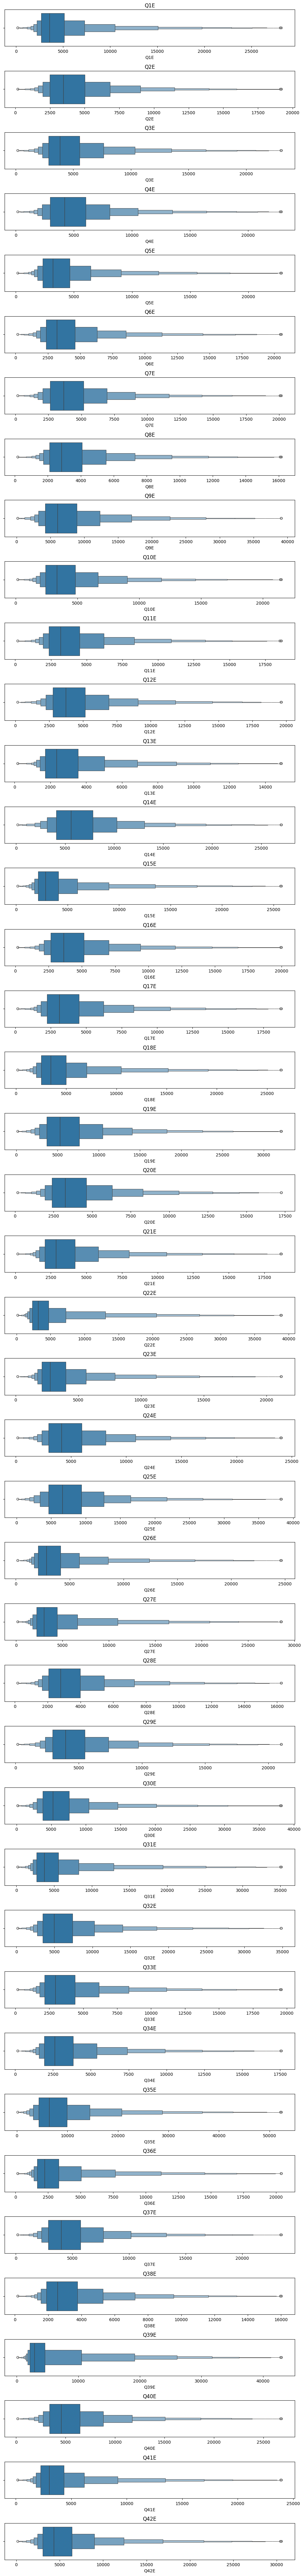

In [21]:
QxE = [f'Q{i}E' for i in range(1, 43)]

fig, axes = plt.subplots(QxE.__len__(), figsize=(10, 2*QxE.__len__()))
for i, col in enumerate(QxE):
    sns.boxenplot(data = df, x = df[col], ax = axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

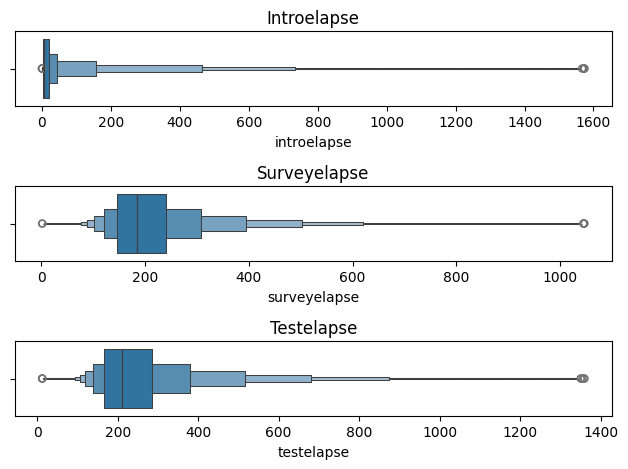

In [22]:
import seaborn as sns

fig, axes = plt.subplots(3) # kalau lebih dari satu plot, gunakan subplot | 3 = row subplot, 1 = column subplot

sns.boxenplot(data = df, x = df['introelapse'], ax=axes[0])
axes[0].set_title('Introelapse')

sns.boxenplot(data = df, x = df['surveyelapse'], ax=axes[1])
axes[1].set_title('Surveyelapse')

sns.boxenplot(data = df, x = df['testelapse'], ax=axes[2])
axes[2].set_title('Testelapse')

plt.tight_layout()
plt.show()

## Model Training

In [23]:
def train_model(scenario_id: int, model_type: str, features: list[str]):
    # Targets (3 columns, values 0..4)
    TASKS = [f for f in target_dimensions.values()] # ["depression_severity","anxiety_severity","stress_severity"]
    
    X = df[features]
      # Use the features from scenario_0 - NOTE - Replace with scenario getter function once everything works.
    y = df[TASKS].astype(int)

    # One-hot to create a multilabel indicator matrix (15 binary columns)
    y_ind = pd.get_dummies(y, columns=TASKS)   # e.g., depression_severity_0..4, anxiety_severity_0..4, stress_severity_0..4

    # Split indexes with iterative multilabel stratification
    msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(msss.split(X, y_ind))

    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Use only those that actually exist in X
    cat_cols = [c for c in candidate_cat_cols if c in X.columns]
    # Everything else in X is treated as numeric (includes TIPI*, age, familysize, interactions, etc.)
    num_cols = [c for c in X.columns if c not in cat_cols]

    if model_type == 'RF':
        # For RF: one-hot categoricals; pass numeric through (no scaling needed for trees)
        preproc_rf = ColumnTransformer([
            ('num', StandardScaler(), num_cols), # No scaling for numeric, passthrough. RF does not require scaling, can be done anyway tho.
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ], remainder='drop')

        # RF pipeline (fair baseline; global class balancing like SVM)
        # NOTE: Pipeline has kbest feature selection for scenario 4.
        if scenario_id == 4:
            rf_pipeline = Pipeline([
                ('prep', preproc_rf),
                ('feature_selection', SelectKBest(score_func=mutual_info_classif, k=20)), # kbest Feature selection
                ('clf', RandomForestClassifier(
                    n_estimators=300, class_weight='balanced',
                    n_jobs=-1, random_state=42
                ))
            ])

        else:
            rf_pipeline = Pipeline([
                ('prep', preproc_rf),
                ('clf', RandomForestClassifier(
                    n_estimators=300, class_weight='balanced',
                    n_jobs=-1, random_state=42
                ))
            ])
        rf_pipeline = MultiOutputClassifier(rf_pipeline)    # Feature selection only expects 1D value from y.
                                                            # Even though RF can do multioutput by itself, multioutput is necessary here because of kbest.
        model = rf_pipeline

    elif model_type == 'SVM':
        
        if scenario_id == 4:
            # For SVM: one-hot categoricals; scale numeric
            preproc_svm = ColumnTransformer([
                ('num', StandardScaler(), num_cols),
                ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
            ], remainder='drop')

            svm_pipeline = Pipeline([
                ('prep', preproc_svm),
                ('feature_selection', SelectKBest(score_func=mutual_info_classif, k=20)), # kbest Feature selection 
                ('svc', SVC(class_weight='balanced', probability=True, random_state=42))
            ])

            svm_pipeline = Pipeline ([
                ('prep', preproc_svm),
                ('svc', SVC(kernel='rbf', C=3, class_weight='balanced', probability=True, random_state=42, gamma='scale'))
            ])

        else:
            preproc_svm = ColumnTransformer([
                ('num', StandardScaler(), num_cols),
                ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
            ], remainder='drop')

            # SVM pipeline (multi-output wrapper; OHE + scaling inside)
            svm_pipeline = Pipeline([
                ('prep', preproc_svm),
                ('svc', SVC(kernel='rbf', C=3, class_weight='balanced', probability=True, random_state=42, gamma='scale'))
            ])
        svm = MultiOutputClassifier(svm_pipeline) # SVM needs to be wrapped in MultiOutputClassifier for multi-label tasks
        model = svm

    # Fit the model
    model.fit(X_train, y_train)
    y_pred = pd.DataFrame(model.predict(X_test), columns=TASKS, index=y_test.index)

    # Print summary of the model performance, for depression, anxiety, stress class
    summary = pd.concat([summarize_task(y_test[t], y_pred[t], t) for t in TASKS])
    print(f"[Scenario {scenario_id}] | {model_type} | - Compact Summary")
    print(summary)
    # Print classification report for each dimension
    for t in TASKS:
        print(f"\n[{t}] | {model_type} - Classification Report")
        print(classification_report(y_test[t], y_pred[t], target_names=[dass_classification_dict[i] for i in range(5)]))
    
    # --- Save fitted model + tiny metadata ---
    os.makedirs("models", exist_ok=True)
    base = f"{model_type}_scenario{scenario_id}"
    joblib.dump(model, f"models/{base}.joblib", compress=3)
    meta = {"scenario_id": scenario_id, "model_type": model_type, "features": features, "tasks": TASKS}
    with open(f"models/{base}.meta.json", "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)
    print(f"[Saved] models/{base}.joblib (+ .meta.json)")

In [26]:
# Declare algorithm var. Used when calling train model function.
algo = ['RF', 'SVM']

In [22]:
# Scenario 0
scenario_id = 0
features = get_features_for_scenario('none', scenario_id)

for a in algo:
    train_model(scenario_id, a, features)

[Scenario 0] | RF | - Compact Summary
                  macro_f1  macro_recall  balanced_acc    mae  support
task                                                                  
depression_class     0.723         0.728         0.728  0.206     7955
anxiety_class        0.590         0.598         0.598  0.322     7955
stress_class         0.782         0.779         0.779  0.184     7955

[depression_class] | RF - Classification Report
                  precision    recall  f1-score   support

          Normal       0.79      0.88      0.83      1772
            Mild       0.43      0.19      0.27       757
        Moderate       0.67      0.79      0.72      1416
          Severe       0.84      0.81      0.82      1295
Extremely Severe       0.96      0.98      0.97      2715

        accuracy                           0.82      7955
       macro avg       0.74      0.73      0.72      7955
    weighted avg       0.80      0.82      0.80      7955


[anxiety_class] | RF - Classific

In [27]:
# Scenario 1
scenario_id = 1
features = get_features_for_scenario('none', scenario_id)

for a in algo:
    train_model(scenario_id, a, features)

[Scenario 1] | RF | - Compact Summary
                     macro_f1  macro_recall  balanced_acc    mae  support
task                                                                     
depression_severity     0.297         0.345         0.345  1.101     7955
anxiety_severity        0.280         0.336         0.336  1.097     7955
stress_severity         0.360         0.383         0.383  0.874     7955

[depression_severity] | RF - Classification Report
                  precision    recall  f1-score   support

          Normal       0.49      0.71      0.58      1772
            Mild       0.11      0.01      0.01       757
        Moderate       0.32      0.16      0.21      1416
          Severe       0.21      0.03      0.06      1295
Extremely Severe       0.50      0.81      0.62      2715

        accuracy                           0.47      7955
       macro avg       0.33      0.34      0.30      7955
    weighted avg       0.38      0.47      0.39      7955


[anxiety_sever

In [28]:
# Scenario 2
scenario_id = 2
features = get_features_for_scenario('none', scenario_id)

for a in algo:
    train_model(scenario_id, a, features)

[Scenario 2] | RF | - Compact Summary
                     macro_f1  macro_recall  balanced_acc    mae  support
task                                                                     
depression_severity     0.293         0.334         0.334  1.145     7955
anxiety_severity        0.279         0.326         0.326  1.137     7955
stress_severity         0.341         0.358         0.358  0.951     7955

[depression_severity] | RF - Classification Report
                  precision    recall  f1-score   support

          Normal       0.48      0.68      0.56      1772
            Mild       0.14      0.02      0.03       757
        Moderate       0.27      0.14      0.18      1416
          Severe       0.22      0.05      0.08      1295
Extremely Severe       0.49      0.79      0.61      2715

        accuracy                           0.45      7955
       macro avg       0.32      0.33      0.29      7955
    weighted avg       0.37      0.45      0.38      7955


[anxiety_sever

In [29]:
# Scenario 3
scenario_id = 3
features = get_features_for_scenario('none', scenario_id)

for a in algo:
    train_model(scenario_id, a, features)

[Scenario 3] | RF | - Compact Summary
                     macro_f1  macro_recall  balanced_acc    mae  support
task                                                                     
depression_severity     0.301         0.344         0.344  1.106     7955
anxiety_severity        0.285         0.336         0.336  1.091     7955
stress_severity         0.350         0.370         0.370  0.908     7955

[depression_severity] | RF - Classification Report
                  precision    recall  f1-score   support

          Normal       0.49      0.70      0.58      1772
            Mild       0.20      0.02      0.03       757
        Moderate       0.29      0.16      0.20      1416
          Severe       0.23      0.05      0.08      1295
Extremely Severe       0.50      0.80      0.62      2715

        accuracy                           0.47      7955
       macro avg       0.34      0.34      0.30      7955
    weighted avg       0.39      0.47      0.39      7955


[anxiety_sever

In [30]:
# Scenario 4
scenario_id = 4
features = get_features_for_scenario('none', scenario_id)

for a in algo:
    train_model(scenario_id, a, features)

[Scenario 4] | RF | - Compact Summary
                     macro_f1  macro_recall  balanced_acc    mae  support
task                                                                     
depression_severity     0.319         0.344         0.344  1.101     7955
anxiety_severity        0.297         0.331         0.331  1.104     7955
stress_severity         0.364         0.377         0.377  0.901     7955

[depression_severity] | RF - Classification Report
                  precision    recall  f1-score   support

          Normal       0.49      0.65      0.56      1772
            Mild       0.19      0.04      0.07       757
        Moderate       0.28      0.21      0.24      1416
          Severe       0.21      0.08      0.12      1295
Extremely Severe       0.52      0.74      0.61      2715

        accuracy                           0.45      7955
       macro avg       0.34      0.34      0.32      7955
    weighted avg       0.39      0.45      0.40      7955


[anxiety_sever